In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1. Load the Silver Data Lake 
# (Pandas with PyArrow is smart enough to read the whole partitioned folder at once)
data_path = ('/Users/nishitawaghela/sentinel/data/silver_trades/')
print(f"Loading Silver Data Lake directly from: {data_path}")
df = pd.read_parquet(data_path)

Loading Silver Data Lake directly from: /Users/nishitawaghela/sentinel/data/silver_trades/


In [4]:
# 2. Map the labels back to readable names
label_map = {
    0: "Normal", 
    1: "Wash Trade", 
    2: "Volume Spike", 
    3: "Spoofing", 
    4: "Front-Running", 
    5: "Flash Crash"
}
df['anomaly_type'] = df['label'].map(label_map)

In [5]:
# 3. Check the exact distribution of our data
print("\n--- Trade Label Distribution ---")
print(df['anomaly_type'].value_counts())


--- Trade Label Distribution ---
anomaly_type
Volume Spike     1320
Flash Crash      1280
Normal           1092
Wash Trade        584
Spoofing          408
Front-Running     320
Name: count, dtype: int64


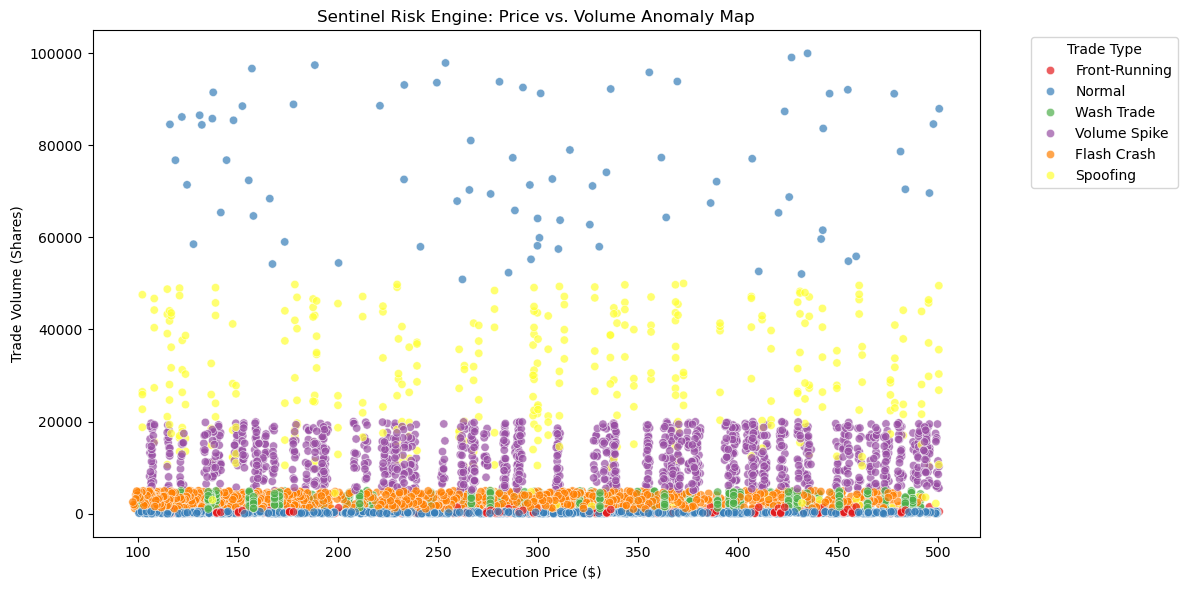

In [6]:
# 4. Visualizing the Fraud (Volume vs. Price)
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, 
    x='price', 
    y='volume', 
    hue='anomaly_type', 
    palette='Set1', 
    alpha=0.7
)
plt.title("Sentinel Risk Engine: Price vs. Volume Anomaly Map")
plt.xlabel("Execution Price ($)")
plt.ylabel("Trade Volume (Shares)")
plt.legend(title="Trade Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
# 1. Feature Engineering (The Upgrade)
# We are adding categorical data: 'action' (BUY/SELL) and 'order_type' (MARKET/LIMIT)
# pd.get_dummies() turns text into 1s and 0s (One-Hot Encoding)
print("Encoding categorical features...")
df_encoded = pd.get_dummies(df, columns=['action', 'order_type'], drop_first=True)

Encoding categorical features...


In [9]:
# Now we give the model more features to look at
features = ['price', 'volume'] + [col for col in df_encoded.columns if 'action_' in col or 'order_type_' in col]
print(f"New ML Features: {features}")

New ML Features: ['price', 'volume', 'action_SELL', 'order_type_MARKET']


In [10]:
X = df_encoded[features]
y = df_encoded['label']

# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# 3. Train the Upgraded Random Forest
print("\nTraining Upgraded Sentinel Risk Engine...")
rf_model_v2 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_v2.fit(X_train, y_train)


Training Upgraded Sentinel Risk Engine...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
# 4. Evaluate the New Model
y_pred_v2 = rf_model_v2.predict(X_test)

print("\n--- UPGRADED Sentinel Model Performance ---")
print(classification_report(y_test, y_pred_v2, target_names=label_map.values()))


--- UPGRADED Sentinel Model Performance ---
               precision    recall  f1-score   support

       Normal       0.86      0.91      0.89       220
   Wash Trade       0.65      0.62      0.63       115
 Volume Spike       1.00      1.00      1.00       251
     Spoofing       1.00      0.76      0.87        89
Front-Running       0.51      0.40      0.45        58
  Flash Crash       0.84      0.93      0.88       268

     accuracy                           0.86      1001
    macro avg       0.81      0.77      0.79      1001
 weighted avg       0.86      0.86      0.86      1001



In [13]:
import os
import joblib

# Define the absolute path based on your Mac's directory
save_dir = '/Users/nishitawaghela/sentinel/ml_engine/saved_models'
os.makedirs(save_dir, exist_ok=True)

# Save the model
model_path = f'{save_dir}/anomaly_detector_v2.pkl'
joblib.dump(rf_model_v2, model_path)

print(f"Model successfully saved to: {model_path}")

Model successfully saved to: /Users/nishitawaghela/sentinel/ml_engine/saved_models/anomaly_detector_v2.pkl
